# Data Structures & Algorithms
# Group Project 2
## Q2: Letters & Word Analysis

### Preprocessing

In [3]:
# Import all dependencies
import re
import string
import math
import collections
import itertools
import wordcloud
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/amberteetsel/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [4]:
# Define file names
input_txt = "Little_Women_Full.txt"
output = "Little_Women.txt"

# Markers for start/end of actual novel
start = "*** START OF THE PROJECT GUTENBERG EBOOK LITTLE WOMEN ***"
end = "*** END OF THE PROJECT GUTENBERG EBOOK LITTLE WOMEN ***"

# Read full text file
with open(input_txt, "r", encoding="utf-8") as file:
    book = file.read()

# Separate main text from Gutenberg markers
if start in book and end in book:
    main_text = book.split(start, 1)[1].split(end, 1)[0].strip()
else:
    raise ValueError("Start or end marker not found")

# Convert to lowercase
main_text = main_text.lower()

# Remove ToC??

# Remove punctuation, digits, and special characters using regular expressions
# Code below keeps only letters
clean_text = re.sub(r'[^a-zA-Z\s]', '', main_text)

# Get rid of newlines, extra whitepsace
clean_text = re.sub(r"\s+", " ", clean_text).strip()
print(clean_text[:2500])

# Write to new clean file
with open(output, "w", encoding="utf-8") as new_file:
    new_file.write(clean_text)

# Tokenize by whitespace
txt = clean_text
tokens = clean_text.split()
print(tokens[:15])

# Remove stopwords using nltk
stop_words = set(stopwords.words('english'))

# Remove punctuation/digits/special characters to match our format
clean_stop_words = [re.sub(r'[^a-zA-Z\s]','', word) for word in list(stop_words)]

words = [t for t in tokens if t not in clean_stop_words]

# get rid of word 'chapter' (so ToC does not affect word analysis)
## This word does appear within the main body of the novel but word is not frequent enough to significantly affect analysis
lw = [word for word in words if word != "chapter"]
print(lw[:15])

little women by louisa may alcott contents part chapter one playing pilgrims chapter two a merry christmas chapter three the laurence boy chapter four burdens chapter five being neighborly chapter six beth finds the palace beautiful chapter seven amys valley of humiliation chapter eight jo meets apollyon chapter nine meg goes to vanity fair chapter ten the pc and po chapter eleven experiments chapter twelve camp laurence chapter thirteen castles in the air chapter fourteen secrets chapter fifteen a telegram chapter sixteen letters chapter seventeen little faithful chapter eighteen dark days chapter nineteen amys will chapter twenty confidential chapter twentyone laurie makes mischief and jo makes peace chapter twentytwo pleasant meadows chapter twentythree aunt march settles the question part chapter twentyfour gossip chapter twentyfive the first wedding chapter twentysix artistic attempts chapter twentyseven literary lessons chapter twentyeight domestic experiences chapter twentynine 

##### Summary of Preprocessing Effects

In [5]:
# Tokens before stopword removal
n_tokens = len(tokens)
print(f"Original Token Count: {n_tokens:,}")
# Tokens after stopword removal
n_lw = len(lw)
print(f"Post-Processing Token Count: {n_lw:,}")
print(f"Percent of Tokens Removed: {(n_tokens-n_lw)/n_tokens:.2%}")

Original Token Count: 186,088
Post-Processing Token Count: 90,565
Percent of Tokens Removed: 51.33%


### Outputs

#### Letter Frequencies

Alphabetical        By Frequency       
         Letter  Count       Letter  Count
0             a  62921            e  95978
1             b  12158            t  66827
2             c  15837            a  62921
3             d  37501            o  59526
4             e  95978            n  51465
5             f  17291            i  50701
6             g  17395            h  48428
7             h  48428            s  47166
8             i  50701            r  45232
9             j   2288            d  37501
10            k   7577            l  34862
11            l  34862            u  22758
12            m  19825            m  19825
13            n  51465            w  18515
14            o  59526            y  18040
15            p  13073            g  17395
16            q    772            f  17291
17            r  45232            c  15837
18            s  47166            p  13073
19            t  66827            b  12158
20            u  22758            k   7577
21            v   7041            v   7041
22            w  18515            j   2288
23            x    881            x    881
24            y  18040            q    772
25            z    290            z    290

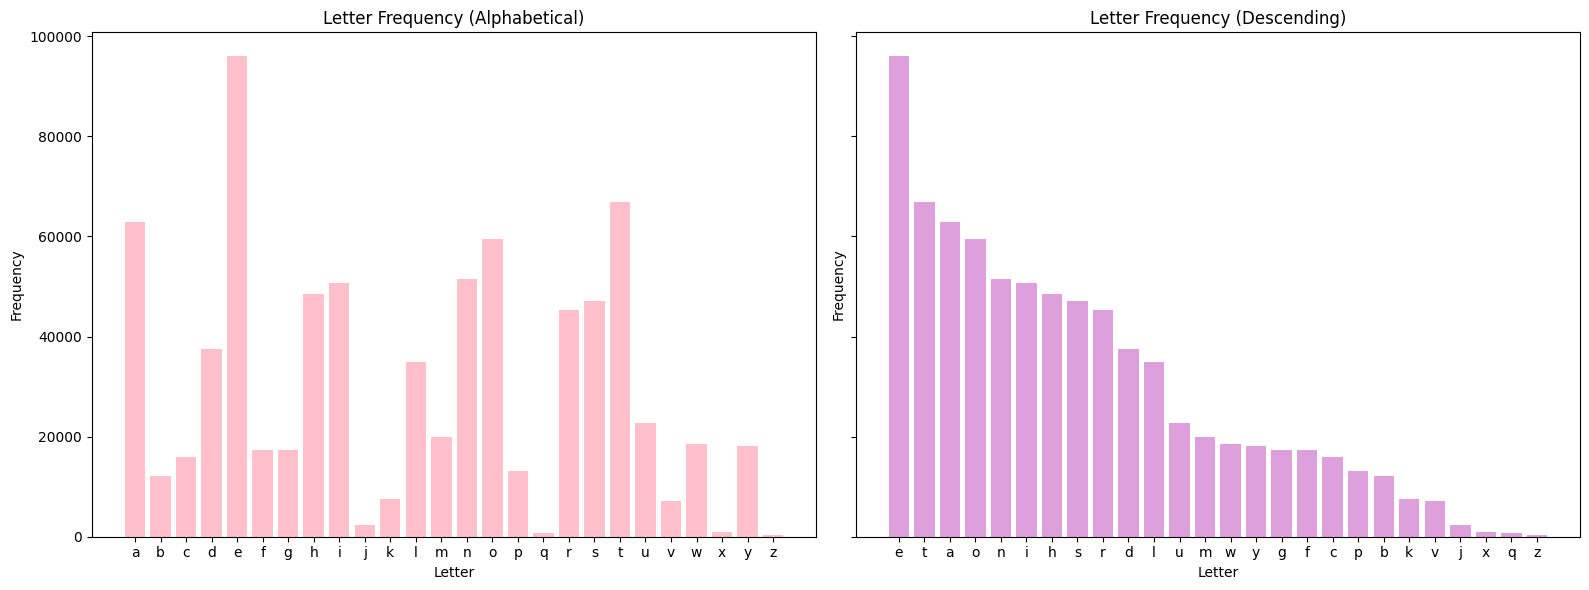

In [6]:
# Get counts
counts = collections.Counter(clean_text)
# Remove whitespace entry
counts.pop(' ', None)
# All letters a-z
az = list(string.ascii_lowercase)
freq = [counts.get(l,0) for l in az]

# DataFrames
df = pd.DataFrame({'Letter':az, 'Count':freq})
df_sorted = df.sort_values(by='Count', ascending=False).reset_index(drop=True)
dfs = pd.concat([df, df_sorted], axis=1, keys=['Alphabetical', 'By Frequency'])
display(dfs)

# Bar Charts
fig, ax = plt.subplots(1,2,figsize = (16,6),sharey=True)

## Alphabetical
ax[0].bar(df.Letter, df.Count, color='pink')
ax[0].set_title('Letter Frequency (Alphabetical)')
ax[0].set_xlabel('Letter')
ax[0].set_ylabel('Frequency')

## By Frequency
ax[1].bar(df_sorted.Letter, df_sorted.Count, color='plum')
ax[1].set_title('Letter Frequency (Descending)')
ax[1].set_xlabel('Letter')
ax[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

#### Word Frequencies (after stopword removal)

,Word,Frequency
0,jo,1247
1,said,826
2,little,725
3,one,702
4,meg,633
5,like,583
6,amy,571
7,laurie,547
8,would,444
9,good,430


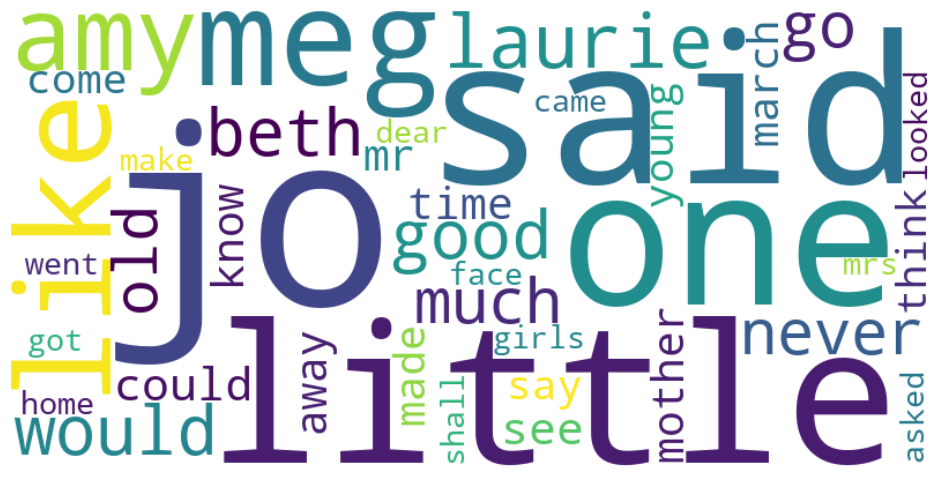

In [7]:
word_counts = collections.Counter(lw)

top40 = word_counts.most_common(40)

df_words = pd.DataFrame(top40, columns=['Word', 'Frequency'])
display(df_words)

# Word Cloud
wc = wordcloud.WordCloud(width=800, height=400, background_color='white', colormap='viridis')
wc.generate_from_frequencies(dict(top40))
plt.figure(figsize=(14,6))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.show()

#### Bigrams & Trigrams

In [23]:
# Tokenize clean version of text so we have each word individually, though this will include stopwords
book = clean_text.strip().split()

# Use itertools to offset list of words by 1 (for bigrams) or 2 (for trigrams) and zip consecutive words together
bigrams = list(zip(book, book[1:]))
trigrams = list(zip(book, book[1:], book[2:]))

# Filter out entries containing stopwords (avoids things like "to the", "i am", etc.)
bigrams_clean = [bg for bg in bigrams if sum(1 for w in bg if w in clean_stop_words) == 0]
trigrams_clean = [tg for tg in trigrams if sum(1 for w in tg if w in clean_stop_words) < 1]

# Get frequencies
bicounts = collections.Counter(bigrams_clean)
tricounts = collections.Counter(trigrams_clean)

# Top 20
bi20 = bicounts.most_common(20)
tri20 = tricounts.most_common(20)

df_bi = pd.DataFrame(bi20, columns=['Bigram', 'Frequency'])
df_tri = pd.DataFrame(tri20, columns=['Trigram', 'Frequency'])

display(df_bi)
display(df_tri)

,Bigram,Frequency
0,"(mrs, march)",142
1,"(said, jo)",118
2,"(aunt, march)",76
3,"(said, meg)",75
4,"(mr, laurence)",67
5,"(mr, brooke)",59
6,"(mr, bhaer)",57
7,"(said, amy)",56
8,"(cried, jo)",51
9,"(old, gentleman)",50


,Trigram,Frequency
0,"(said, mrs, march)",25
1,"(said, meg, looking)",7
2,"(said, mr, brooke)",7
3,"(mrs, march, said)",6
4,"(old, mr, laurence)",6
5,"(said, jo, decidedly)",6
6,"(asked, mrs, march)",6
7,"(said, jo, looking)",5
8,"(mrs, march, looked)",5
9,"(bad, effect, upon)",5


#### Discussion

##### Big-O Complexity

##### Interpretation of Text Distributions